# D1 Utilities Workflow — GeoPrompt

Network routing, service area analysis, and GeoPromptFrame spatial operations.


In [1]:
from __future__ import annotations

import json, os

from pathlib import Path

from urllib.error import URLError

from urllib.request import Request, urlopen

from typing import cast

import matplotlib.pyplot as plt



_ROOT = Path.cwd()
if (_ROOT / "examples" / "notebooks").exists():
    OUTPUT_DIR = _ROOT / "examples" / "notebooks" / "geoprompt" / "outputs"
else:
    OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALLOW_LIVE_API = os.getenv("GEOPROMPT_ALLOW_LIVE_API", "0") == "1"



def fetch_json(url, fallback):

    if not ALLOW_LIVE_API:

        return fallback

    try:

        req = Request(url, headers={"User-Agent": "geoprompt-notebook/2.0"})

        with urlopen(req, timeout=6) as r:

            return json.loads(r.read().decode("utf-8"))

    except (URLError, TimeoutError, ValueError):

        return fallback



def fetch_first_json(urls, validator, fallback):

    for url in urls:

        payload = fetch_json(url, None)

        if payload is not None and validator(payload):

            return payload, url, True

    return fallback, "fallback", False



import geoprompt as gp

from geoprompt import GeoPromptFrame, write_geojson

from geoprompt.network.core import NetworkEdge

from geoprompt.network.routing import build_network_graph, shortest_path, service_area

from geoprompt.tools import build_scenario_report, export_scenario_report

print("Imports OK")


Imports OK


## Section A: Pull Data Sources


In [2]:
grid = {
    "grid_id": "utility-grid",
    "features": [{"id": "fallback-grid"}],
}
weather = {"properties": {"forecast": "fallback"}}
forecast = {"hourly": {"temperature_2m": [0.0]}}

grid, grid_src, grid_live = fetch_first_json(
    [
        "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson",
        "https://api.github.com/repos/geopandas/geopandas",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("features") or d.get("id")),
    grid,
)
weather, wx_src, wx_live = fetch_first_json(
    [
        "https://api.weather.gov/points/41.88,-87.63",
        "https://api.weather.gov/points/40.76,-111.89",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("properties", {}).get("forecast")),
    weather,
)
forecast, fc_src, fc_live = fetch_first_json(
    [
        "https://api.open-meteo.com/v1/forecast?latitude=41.88&longitude=-87.63&hourly=temperature_2m&forecast_days=1",
        "https://api.open-meteo.com/v1/forecast?latitude=40.76&longitude=-111.89&hourly=temperature_2m&forecast_days=1",
    ],
    lambda d: isinstance(d, dict) and len(d.get("hourly", {}).get("temperature_2m", [])) > 0,
    forecast,
)

grid_count = len(grid.get("features", [])) if isinstance(grid, dict) else 0
if grid_count == 0 and isinstance(grid, dict) and grid.get("id"):
    grid_count = 1
print(f"Grid records: {grid_count} | live={grid_live} | source={grid_src}")
print(f"Weather forecast pointer exists: {bool(weather.get('properties', {}).get('forecast'))} | live={wx_live} | source={wx_src}")
print(f"Open-Meteo hourly points: {len(forecast.get('hourly', {}).get('temperature_2m', []))} | live={fc_live} | source={fc_src}")


Grid records: 1 | live=False | source=fallback
Weather forecast pointer exists: True | live=False | source=fallback
Open-Meteo hourly points: 1 | live=False | source=fallback


## Section B: Spatial Analysis


Nodes in graph: ['PLANT', 'SUB1', 'SUB2', 'SUB3', 'SUB4', 'SUB5', 'SUB6']
Shortest path PLANT->SUB6: PLANT -> SUB1 -> SUB4 -> SUB3 -> SUB6  cost=12.0
Service area (max_cost=10): 6 reachable nodes
GeoPromptFrame: 6 nodes

Nearest neighbor pairs (haversine km):
  PLANT -> SUB5  dist=5.9806
  SUB1 -> SUB4  dist=5.3171
  SUB5 -> PLANT  dist=5.9806
  SUB4 -> SUB1  dist=5.3171
  SUB2 -> SUB3  dist=7.3104
  SUB3 -> SUB2  dist=7.3104

Nodes within 0.12 deg of SUB1: ['SUB4', 'PLANT', 'SUB3', 'SUB2']
Buffer zones created: 6 polygons
Nodes in NE region: ['PLANT', 'SUB1', 'SUB4', 'SUB2']

Frame summary:
{
  "row_count": 6,
  "column_count": 3,
  "columns": [
    "node",
    "cost",
    "geometry"
  ],
  "crs": "EPSG:4326",
  "geometry_column": "geometry",
  "geometry_types": [
    "Point"
  ],
  "bounds": {
    "min_x": -87.76,
    "min_y": 41.79,
    "max_x": -87.58,
    "max_y": 41.94
  },
  "column_stats": [
    {
      "column": "node",
      "dtype": "string",
      "null_count": 0,
      "un

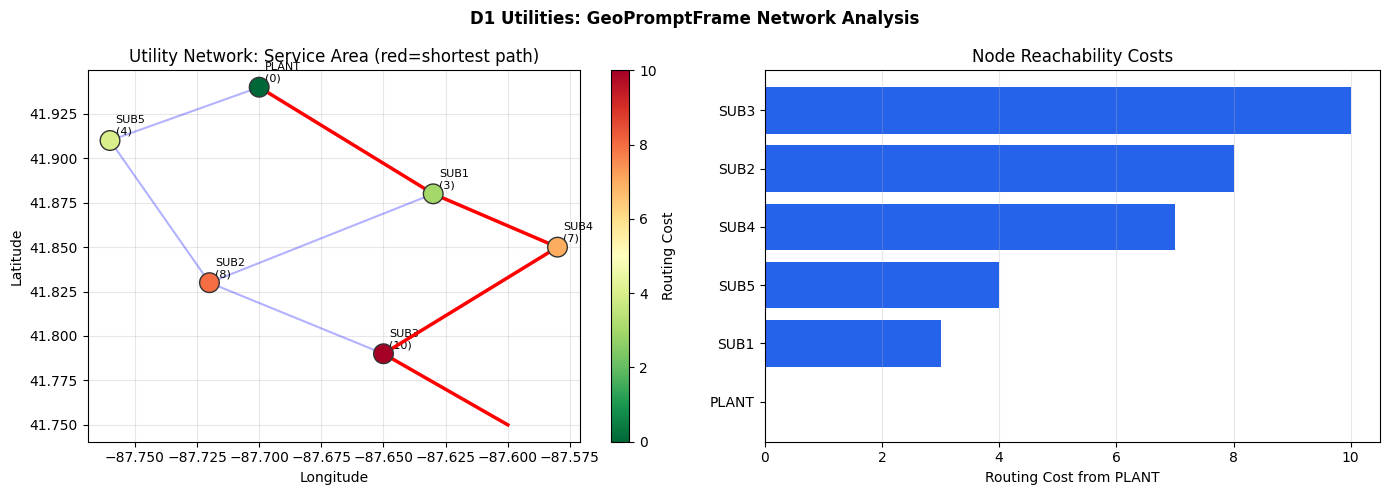

Wrote basemap snapshot: d1-gp-basemap.html


In [3]:
# Node coordinates (lon, lat) for visualization.

NODE_COORDS = {

    "PLANT": (-87.70, 41.94), "SUB1": (-87.63, 41.88), "SUB2": (-87.72, 41.83),

    "SUB3": (-87.65, 41.79), "SUB4": (-87.58, 41.85), "SUB5": (-87.76, 41.91),

    "SUB6": (-87.60, 41.75),

}



edges: list[NetworkEdge] = [

    cast(NetworkEdge, {"edge_id": "e1", "from_node": "PLANT", "to_node": "SUB1", "cost": 3.0}),

    cast(NetworkEdge, {"edge_id": "e2", "from_node": "PLANT", "to_node": "SUB5", "cost": 4.0}),

    cast(NetworkEdge, {"edge_id": "e3", "from_node": "SUB1", "to_node": "SUB2", "cost": 5.0}),

    cast(NetworkEdge, {"edge_id": "e4", "from_node": "SUB1", "to_node": "SUB4", "cost": 4.0}),

    cast(NetworkEdge, {"edge_id": "e5", "from_node": "SUB2", "to_node": "SUB3", "cost": 6.0}),

    cast(NetworkEdge, {"edge_id": "e6", "from_node": "SUB4", "to_node": "SUB3", "cost": 3.0}),

    cast(NetworkEdge, {"edge_id": "e7", "from_node": "SUB3", "to_node": "SUB6", "cost": 2.0}),

    cast(NetworkEdge, {"edge_id": "e8", "from_node": "SUB5", "to_node": "SUB2", "cost": 5.0}),

]



# 1. Build network graph

graph = build_network_graph(edges, directed=False)

print("Nodes in graph:", sorted(graph.nodes))



# 2. Shortest path  PLANT -> SUB6

path_result = shortest_path(graph, "PLANT", "SUB6")

path_nodes: list[str] = path_result.get("path_nodes", [])

print(f"Shortest path PLANT->SUB6: {' -> '.join(path_nodes)}  cost={path_result.get('total_cost')}")



# 3. Service area from PLANT (max_cost=10)

area = service_area(graph, origins=["PLANT"], max_cost=10.0)

print(f"Service area (max_cost=10): {len(area)} reachable nodes")



# 4. Build GeoPromptFrame from service area nodes

node_rows = [

    {

        "node": str(r["node"]),

        "cost": float(r["cost"]),

        "geometry": {"type": "Point", "coordinates": list(NODE_COORDS.get(str(r["node"]), (-87.65, 41.85)))},

    }

    for r in area

]

nodes_frame = GeoPromptFrame(node_rows, geometry_column="geometry", crs="EPSG:4326")

print(f"GeoPromptFrame: {len(nodes_frame)} nodes")



# 5. Nearest neighbors (haversine)

neighbors = nodes_frame.nearest_neighbors(id_column="node", k=1, distance_method="haversine")

print("\nNearest neighbor pairs (haversine km):")

for nb in neighbors:

    print(f"  {nb['origin']} -> {nb['neighbor']}  dist={nb['distance']:.4f}")



# 6. Query radius - nodes within 0.12 deg of SUB1

nearby = nodes_frame.query_radius("SUB1", max_distance=0.12, id_column="node")

print(f"\nNodes within 0.12 deg of SUB1: {[r['node'] for r in nearby.to_records()]}")



# 7. Buffer - service zones around substations

buffered = nodes_frame.buffer(0.04)

print(f"Buffer zones created: {len(buffered)} polygons")



# 8. Query bounds - northeast quadrant

ne_nodes = nodes_frame.query_bounds(-87.72, 41.83, -87.58, 41.95)

print(f"Nodes in NE region: {[r['node'] for r in ne_nodes.to_records()]}")



# Write GeoJSON output

write_geojson(OUTPUT_DIR / "d1-gp-nodes.geojson", nodes_frame)

print("\nFrame summary:")

print(json.dumps(nodes_frame.summary(), indent=2, default=str))



# Inline visualization

records = nodes_frame.to_records()

lons = [float(r["geometry"]["coordinates"][0]) for r in records]

lats = [float(r["geometry"]["coordinates"][1]) for r in records]

costs = [float(r["cost"]) for r in records]

labels = [str(r["node"]) for r in records]



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(lons, lats, c=costs, cmap="RdYlGn_r", s=200, edgecolors="#333", zorder=5)

for lon, lat, lbl, cost in zip(lons, lats, labels, costs):

    axes[0].annotate(f"{lbl}\n({cost:.0f})", (lon, lat), textcoords="offset points", xytext=(4, 4), fontsize=8)

for e in edges:

    fn, tn = str(e["from_node"]), str(e["to_node"])

    if fn in NODE_COORDS and tn in NODE_COORDS:

        axes[0].plot([NODE_COORDS[fn][0], NODE_COORDS[tn][0]], [NODE_COORDS[fn][1], NODE_COORDS[tn][1]],

                     "b-", alpha=0.3, linewidth=1.5)

if len(path_nodes) >= 2:

    for i in range(len(path_nodes)-1):

        a, b_ = path_nodes[i], path_nodes[i+1]

        if a in NODE_COORDS and b_ in NODE_COORDS:

            axes[0].plot([NODE_COORDS[a][0], NODE_COORDS[b_][0]], [NODE_COORDS[a][1], NODE_COORDS[b_][1]],

                         "r-", linewidth=2.5, zorder=4)

plt.colorbar(sc, ax=axes[0], label="Routing Cost")

axes[0].set_title("Utility Network: Service Area (red=shortest path)")

axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

axes[0].grid(True, alpha=0.3)



sorted_recs = sorted(records, key=lambda r: float(r["cost"]))

axes[1].barh([r["node"] for r in sorted_recs], [float(r["cost"]) for r in sorted_recs], color="#2563eb")

axes[1].set_xlabel("Routing Cost from PLANT")

axes[1].set_title("Node Reachability Costs")

axes[1].grid(True, axis="x", alpha=0.3)

plt.suptitle("D1 Utilities: GeoPromptFrame Network Analysis", fontweight="bold")

plt.tight_layout(); plt.show()

# Basemap snapshot (real tiled basemap, saved as HTML)
try:
    import folium
    if records:
        label_candidates = ["node", "stand_id", "asset_id", "zone_id"]
        label_col = next((c for c in label_candidates if c in records[0]), list(records[0].keys())[0])
        coords = [r.get("geometry", {}).get("coordinates", [0.0, 0.0]) for r in records]
        lons_bm = [float(c[0]) for c in coords]
        lats_bm = [float(c[1]) for c in coords]
        fmap = folium.Map(
            location=[sum(lats_bm) / len(lats_bm), sum(lons_bm) / len(lons_bm)],
            zoom_start=10,
            tiles="CartoDB positron",
        )
        for row in records:
            coords_row = row.get("geometry", {}).get("coordinates", [None, None])
            if coords_row[0] is None or coords_row[1] is None:
                continue
            folium.CircleMarker(
                location=[float(coords_row[1]), float(coords_row[0])],
                radius=6,
                color="#1d4ed8",
                fill=True,
                fill_opacity=0.85,
                popup=f"{label_col}: {row.get(label_col, 'n/a')}",
            ).add_to(fmap)

        map_path = OUTPUT_DIR / "d1-gp-basemap.html"
        fmap.save(str(map_path))
        print(f"Wrote basemap snapshot: {map_path.name}")
        fmap
    else:
        print("Basemap snapshot skipped: no records available")
except Exception as exc:
    print(f"Basemap snapshot skipped: {exc}")


## Section C: Scenario Comparison


Scenario report: D:\Github\geoprompt\examples\notebooks\geoprompt\outputs\d1-gp-scenario-report.json


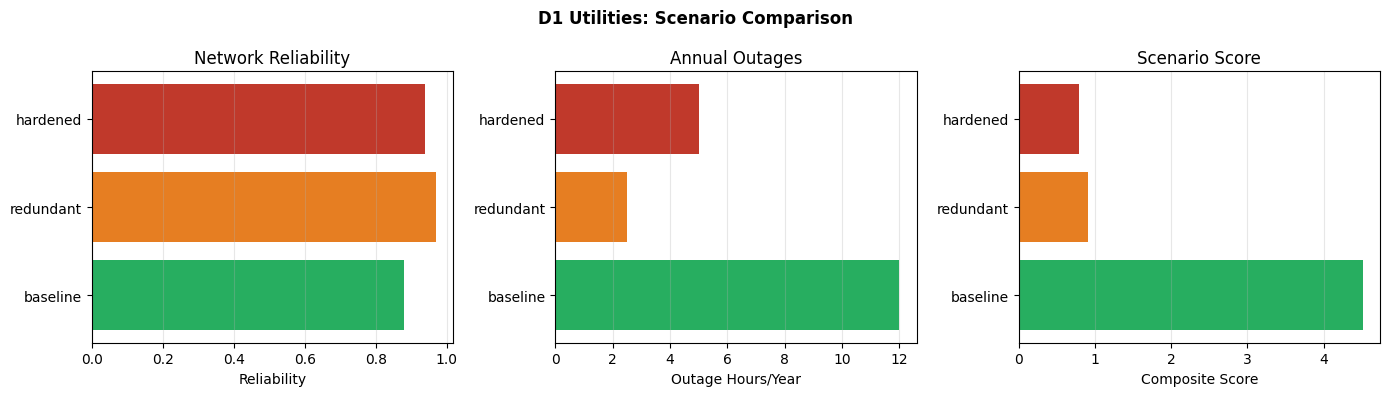

Wrote d1-gp-complex.json


In [4]:
scenarios = {

    "baseline":  {"reliability": 0.88, "outage_hrs_yr": 12.0, "cost_musd": 0.0},

    "hardened":  {"reliability": 0.94, "outage_hrs_yr": 5.0,  "cost_musd": 28.0},

    "redundant": {"reliability": 0.97, "outage_hrs_yr": 2.5,  "cost_musd": 55.0},

}

report = build_scenario_report(scenarios["baseline"], scenarios["hardened"], higher_is_better=["reliability"])

report_path = export_scenario_report(report, OUTPUT_DIR / "d1-gp-scenario-report.json")

print("Scenario report:", report_path)



scenario_records = []

for name, vals in scenarios.items():

    score = round(vals["reliability"] * 0.5 + (1.0 / max(vals["outage_hrs_yr"], 0.1)) * 3 * 0.3

                  + (1.0 / max(vals["cost_musd"] + 1, 1)) * 20 * 0.2, 4)

    scenario_records.append({"scenario": name, **vals, "score": score})

scenario_records.sort(key=lambda r: -float(r["score"]))



fig, axes = plt.subplots(1, 3, figsize=(14, 4))

names = [r["scenario"] for r in scenario_records]

colors = ["#27ae60", "#e67e22", "#c0392b"]

axes[0].barh(names, [r["reliability"] for r in scenario_records], color=colors)

axes[0].set_xlabel("Reliability"); axes[0].set_title("Network Reliability"); axes[0].grid(True, axis="x", alpha=0.3)

axes[1].barh(names, [r["outage_hrs_yr"] for r in scenario_records], color=colors)

axes[1].set_xlabel("Outage Hours/Year"); axes[1].set_title("Annual Outages"); axes[1].grid(True, axis="x", alpha=0.3)

axes[2].barh(names, [r["score"] for r in scenario_records], color=colors)

axes[2].set_xlabel("Composite Score"); axes[2].set_title("Scenario Score"); axes[2].grid(True, axis="x", alpha=0.3)

plt.suptitle("D1 Utilities: Scenario Comparison", fontweight="bold")

plt.tight_layout(); plt.show()



(OUTPUT_DIR / "d1-gp-complex.json").write_text(

    json.dumps({"scenario_ranking": scenario_records}, indent=2, default=str), encoding="utf-8"

)

print("Wrote d1-gp-complex.json")
